# Week 7 — Complete Machine Learning Workflow

## Putting It All Together

This notebook combines the main machine learning skills I learned during Week 7:

1. Data cleaning
2. Feature engineering
3. Training multiple models
4. Cross-validation
5. Model selection
6. Final test evaluation

The goal is to complete one clean and trustworthy machine learning workflow.

## Project Question

**Which beginner machine learning model performs best when predicting the wine class from chemical measurements?**

I will compare K-Nearest Neighbors, Decision Tree and Logistic Regression.

The models will be compared using 5-fold cross-validation before the best model is evaluated on a held-out test set.

## Complete Machine Learning Workflow

The complete workflow used in this notebook is:

**Clean → Engineer features → Split → Train multiple models → Cross-validate → Select the best model → Evaluate on test data → Conclude**

Each stage supports the next stage.

Cleaning improves the quality of the dataset. Feature engineering improves the inputs. Cross-validation helps compare models fairly. The held-out test set provides the final honest evaluation.

## Why This Workflow Is Repeatable

This general workflow can be used for many machine learning problems.

The dataset, target, features, models and evaluation metric may change, but the main process remains similar.

Following a clear workflow also makes the project easier to understand, reproduce and improve.

## What Makes a Machine Learning Result Trustworthy?

A trustworthy result should come from a fair comparison.

All models should use the same data, the same cross-validation folds and the same evaluation metric.

The final test data should remain separate while the models are being compared. Limitations should also be explained honestly instead of claiming that one high score proves the model is perfect.

In [28]:
# Import the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold
)

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## Library Explanation

The main libraries used are:

- pandas for data tables
- NumPy for numerical operations
- matplotlib for the confusion matrix
- scikit-learn for data splitting, preprocessing, models and evaluation

Pipeline and ColumnTransformer will keep the preprocessing steps connected to each model.

In [29]:
# Load the Wine dataset

wine = load_wine()

print("The Wine dataset has been loaded successfully.")

The Wine dataset has been loaded successfully.


In [30]:
# Convert the dataset into a pandas DataFrame

df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

# Add the target column

df["target"] = wine.target

# Add readable target names

df["wine_class"] = df["target"].map({
    0: "Class 0",
    1: "Class 1",
    2: "Class 2"
})

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,Class 0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,Class 0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,Class 0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,Class 0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,Class 0


In [31]:
# Check the dataset shape and class distribution

print("Dataset shape:", df.shape)

print("\nNumber of samples in each class:")
print(df["wine_class"].value_counts())

Dataset shape: (178, 15)

Number of samples in each class:
wine_class
Class 1    71
Class 0    59
Class 2    48
Name: count, dtype: int64


## Dataset Information

The Wine dataset contains 178 wine samples.

Each sample contains chemical measurements such as alcohol, magnesium, total phenols, flavanoids and proline.

The target contains one of three wine classes.

In [32]:
# Check data types and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [33]:
# Check missing values and duplicate rows

total_missing_values = df.isnull().sum().sum()
duplicate_rows = df.duplicated().sum()

print("Total missing values:", total_missing_values)
print("Duplicate rows:", duplicate_rows)

Total missing values: 0
Duplicate rows: 0


In [34]:
# Display the statistical summary

df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


## Cleaning Decision

The first inspection showed that the dataset contains no missing values and no duplicate rows.

The feature columns are already numerical and suitable for machine learning.

Therefore, I do not need to remove or replace any records. I will keep all 178 wine samples.

In [35]:
# Create a categorical alcohol level feature

df["alcohol_level"] = pd.cut(
    df["alcohol"],
    bins=[
        -np.inf,
        12.5,
        13.5,
        np.inf
    ],
    labels=[
        "Low",
        "Medium",
        "High"
    ]
)

df[
    [
        "alcohol",
        "alcohol_level"
    ]
].head(10)

,alcohol,alcohol_level
0,14.23,High
1,13.20,Medium
2,13.16,Medium
3,14.37,High
4,13.24,Medium
5,14.20,High
6,14.39,High
7,14.06,High
8,14.83,High
9,13.86,High


## Alcohol Level Feature

The original alcohol feature contains continuous numerical values.

I grouped the values into Low, Medium and High categories. This creates a simpler categorical description of the alcohol measurement.

The categories will later be converted into numerical columns using one-hot encoding.

In [36]:
# Create a new ratio feature

df["phenol_ratio"] = (
    df["total_phenols"] /
    (df["flavanoids"] + 0.001)
)

df[
    [
        "total_phenols",
        "flavanoids",
        "phenol_ratio"
    ]
].head()

,total_phenols,flavanoids,phenol_ratio
0,2.80,3.06,0.914734
1,2.65,2.76,0.959797
2,2.80,3.24,0.863931
3,3.85,3.49,1.102836
4,2.80,2.69,1.040505


## Phenol Ratio Feature

I created the phenol_ratio feature by dividing total phenols by flavanoids.

Both columns describe chemical properties of the wine. The ratio may help the models understand the relationship between these measurements.

The small value 0.001 was added to prevent division by zero.

In [37]:
# Check the created features

print("Alcohol level categories:")
print(df["alcohol_level"].value_counts())

print("\nPhenol ratio summary:")
print(df["phenol_ratio"].describe())

Alcohol level categories:
alcohol_level
Medium    66
Low       57
High      55
Name: count, dtype: int64

Phenol ratio summary:
count    178.000000
mean       1.411302
std        0.719500
min        0.625861
25%        0.945817
50%        1.065675
75%        1.605573
max        3.860233
Name: phenol_ratio, dtype: float64


In [38]:
# Store the original numerical feature names

original_numeric_features = list(
    wine.feature_names
)

# Add the engineered numerical feature

numeric_features = (
    original_numeric_features +
    ["phenol_ratio"]
)

# Store the categorical feature

categorical_features = [
    "alcohol_level"
]

# Combine all selected feature names

feature_columns = (
    numeric_features +
    categorical_features
)

# Create X and y

X = df[feature_columns]
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (178, 15)
y shape: (178,)


## Understanding X and y

X contains the model inputs.

It includes:

- The original chemical measurements
- The new phenol ratio
- The alcohol level category

y contains the correct wine class.

The target is kept separate from X to prevent data leakage.

In [39]:
# Create a held-out train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 142
Testing samples: 36


## Why the Test Set Is Held Out

The test set will not be used while comparing the models.

Cross-validation will be performed only on the training data.

After the best model is selected, the held-out test set will be used once for the final evaluation. This gives a more honest estimate of performance on unseen data.

In [40]:
# Create the preprocessing steps

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

print("The preprocessing steps have been created.")

The preprocessing steps have been created.


## Preprocessing Decisions

StandardScaler will scale the numerical features so that large-value columns do not unfairly control models such as KNN.

OneHotEncoder will convert the Low, Medium and High alcohol categories into numerical columns.

The preprocessing is placed inside a pipeline so it is learned only from the training portion during every cross-validation fold.

In [41]:
# Create the three models

models = {
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000
    )
}

print("Models prepared:")

for model_name in models:
    print("-", model_name)

Models prepared:
- K-Nearest Neighbors
- Decision Tree
- Logistic Regression


## Models Selected

Three beginner classification models will be compared:

### K-Nearest Neighbors

KNN predicts using the closest training examples.

### Decision Tree

The Decision Tree uses a series of decision rules.

### Logistic Regression

Logistic Regression learns boundaries between the target classes.

In [42]:
# Create five balanced cross-validation folds

cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("5-fold stratified cross-validation has been created.")

5-fold stratified cross-validation has been created.


## Cross-Validation Plan

The training data will be divided into five balanced folds.

Each model will be trained and tested five times.

The average accuracy and standard deviation will be used to compare the models more reliably than one split.

In [43]:
# Store the model pipelines and results

model_pipelines = {}
comparison_results = []

for model_name, model in models.items():

    # Create a pipeline for this model

    pipeline = Pipeline(
        steps=[
            (
                "preprocessing",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

    # Store the pipeline

    model_pipelines[model_name] = pipeline

    # Run cross-validation only on training data

    fold_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cross_validation,
        scoring="accuracy"
    )

    # Store the results

    comparison_results.append({
        "Model": model_name,
        "Fold 1": fold_scores[0],
        "Fold 2": fold_scores[1],
        "Fold 3": fold_scores[2],
        "Fold 4": fold_scores[3],
        "Fold 5": fold_scores[4],
        "Mean Accuracy": fold_scores.mean(),
        "Standard Deviation": fold_scores.std()
    })

print("Cross-validation completed for all models.")

Cross-validation completed for all models.


In [44]:
# Convert the results into a DataFrame

results_df = pd.DataFrame(
    comparison_results
)

# Sort from highest to lowest mean accuracy

results_df = results_df.sort_values(
    by="Mean Accuracy",
    ascending=False
).reset_index(drop=True)

results_df

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean Accuracy,Standard Deviation
0,Logistic Regression,0.965517,1.000000,1.000000,1.000000,0.928571,0.978818,0.028452
1,K-Nearest Neighbors,0.931034,1.000000,0.928571,0.964286,0.964286,0.957635,0.026213
2,Decision Tree,0.793103,0.896552,0.928571,0.892857,0.964286,0.895074,0.057127


In [45]:
# Create an easier percentage comparison table

percentage_results = results_df.copy()

score_columns = [
    "Fold 1",
    "Fold 2",
    "Fold 3",
    "Fold 4",
    "Fold 5",
    "Mean Accuracy",
    "Standard Deviation"
]

percentage_results[score_columns] = (
    percentage_results[score_columns] * 100
).round(2)

percentage_results

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean Accuracy,Standard Deviation
0,Logistic Regression,96.55,100.00,100.00,100.00,92.86,97.88,2.85
1,K-Nearest Neighbors,93.10,100.00,92.86,96.43,96.43,95.76,2.62
2,Decision Tree,79.31,89.66,92.86,89.29,96.43,89.51,5.71


In [46]:
# Print each model's fold results clearly

for _, row in percentage_results.iterrows():

    print("\nModel:", row["Model"])

    print(
        "Fold scores:",
        row["Fold 1"],
        row["Fold 2"],
        row["Fold 3"],
        row["Fold 4"],
        row["Fold 5"]
    )

    print(
        f"Mean Accuracy: "
        f"{row['Mean Accuracy']:.2f}%"
    )

    print(
        f"Standard Deviation: "
        f"{row['Standard Deviation']:.2f}%"
    )


Model: Logistic Regression
Fold scores: 96.55 100.0 100.0 100.0 92.86
Mean Accuracy: 97.88%
Standard Deviation: 2.85%

Model: K-Nearest Neighbors
Fold scores: 93.1 100.0 92.86 96.43 96.43
Mean Accuracy: 95.76%
Standard Deviation: 2.62%

Model: Decision Tree
Fold scores: 79.31 89.66 92.86 89.29 96.43
Mean Accuracy: 89.51%
Standard Deviation: 5.71%


## Cross-Validation Comparison

Logistic Regression achieved the highest average cross-validation accuracy.

K-Nearest Neighbors also performed well, while the Decision Tree produced a lower average and a larger standard deviation.

The comparison suggests that Logistic Regression was the most accurate and reliable model for this dataset.

In [47]:
# Identify the model with the highest CV mean

best_model_name = results_df.loc[
    0,
    "Model"
]

best_cv_mean = results_df.loc[
    0,
    "Mean Accuracy"
]

best_cv_std = results_df.loc[
    0,
    "Standard Deviation"
]

print("Best model:", best_model_name)

print(
    f"Best CV mean accuracy: "
    f"{best_cv_mean:.2%}"
)

print(
    f"Best CV standard deviation: "
    f"{best_cv_std:.2%}"
)

Best model: Logistic Regression
Best CV mean accuracy: 97.88%
Best CV standard deviation: 2.85%


## Why Logistic Regression Was Selected

Logistic Regression was selected because it achieved the highest average accuracy across the five cross-validation folds.

Its scores were also reasonably stable.

The decision was made using the training data and cross-validation results, not the final test set.

In [48]:
# Get the winning pipeline

best_pipeline = model_pipelines[
    best_model_name
]

# Train it using all available training data

best_pipeline.fit(
    X_train,
    y_train
)

print(
    best_model_name,
    "has been trained using the full training set."
)

Logistic Regression has been trained using the full training set.


In [49]:
# Make predictions on the held-out test set

test_predictions = best_pipeline.predict(
    X_test
)

# Calculate final test accuracy

test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

print(
    f"Final Test Accuracy: "
    f"{test_accuracy:.2%}"
)

Final Test Accuracy: 100.00%


## Final Test Accuracy

The selected Logistic Regression model achieved approximately 100% accuracy on the held-out test set.

This means that it correctly predicted all 36 test examples for this particular split.

However, the test set is small, so this result should not be interpreted as proof that the model will always be perfect.

In [50]:
# Calculate the confusion matrix

confusion_matrix_result = confusion_matrix(
    y_test,
    test_predictions
)

print("Confusion Matrix:")
print(confusion_matrix_result)

Confusion Matrix:
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]


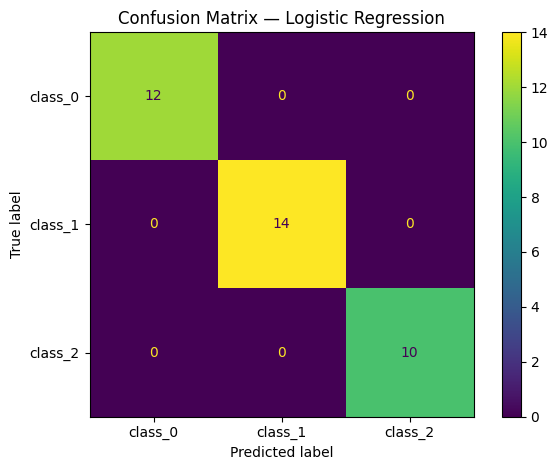

In [51]:
# Display the confusion matrix

display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_result,
    display_labels=wine.target_names
)

display.plot()

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.tight_layout()
plt.show()

## Confusion Matrix Insight

The confusion matrix shows how many samples from each wine class were predicted correctly or incorrectly.

In this test split, the model correctly classified all samples from the three classes, and no incorrect predictions appeared.

In [52]:
# Print the classification report

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=wine.target_names
    )
)

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



## Classification Report Observation

The classification report provides precision, recall and F1-score for each wine class.

The strong results show that the selected model performed well across all three classes in this test set.

The model did not achieve its result by predicting only one class.

In [53]:
# Create the final result summary

final_summary = pd.DataFrame({
    "Item": [
        "Selected Model",
        "Cross-Validation Mean",
        "Cross-Validation Standard Deviation",
        "Held-Out Test Accuracy",
        "Training Samples",
        "Testing Samples"
    ],
    "Result": [
        best_model_name,
        f"{best_cv_mean:.2%}",
        f"{best_cv_std:.2%}",
        f"{test_accuracy:.2%}",
        len(X_train),
        len(X_test)
    ]
})

final_summary

,Item,Result
0,Selected Model,Logistic Regression
1,Cross-Validation Mean,97.88%
2,Cross-Validation Standard Deviation,2.85%
3,Held-Out Test Accuracy,100.00%
4,Training Samples,142
5,Testing Samples,36


## Final Conclusion

Logistic Regression was the best model in this workflow.

It achieved the highest 5-fold cross-validation average of approximately 97.88%, with a standard deviation of approximately 2.85%.

After model selection, Logistic Regression was trained using the full training set and evaluated on the held-out test set. It achieved approximately 100% test accuracy.

I selected this model because it produced the highest cross-validation average and stable results across the folds.

Feature scaling likely helped Logistic Regression and KNN by placing the numerical measurements on a similar scale. The alcohol level category and phenol ratio also provided additional representations of the original data.

## Limitation

One limitation is that the Wine dataset contains only 178 samples.

The held-out test set contained only 36 samples, so a small number of different predictions could noticeably change the test accuracy.

The feature engineering choices were also simple and manually selected. Future work could test each engineered feature separately and use a larger external dataset.

## Final Reflection

This task helped me combine data preparation, feature engineering, model comparison, cross-validation and final evaluation into one complete workflow.

I learned that model selection should be based on a fair comparison using training data. The test data should remain separate until the final model is selected.

I also learned that a trustworthy result should include the evaluation method, model performance and project limitations instead of reporting only one high accuracy score.